# 🏗️ 회귀 세션 과제

실습에서는 모델을 만들고, `summary()`를 읽고, 가정을 검정하고, 잔차를 들여다봤었죠?

이번 과제에서는 이렇게 따져본 결과를 가지고, 모델을 실제로 고쳐볼 예정입니다.



---

## 진행 방식

- 막히면 **▶ 접힌 힌트**를 펼쳐 보셔도 괜찮습니다.
- 모델을 비교할 때는 **항상 테스트 데이터 기준**으로 봐야 합니다!

In [66]:
# 들어가기 전, 그래프의 한글 깨짐을 방지하는 코드입니다. 실행해 주세요!

import platform
import matplotlib.pyplot as plt

# OS별 한글 폰트 설정
if platform.system() == "Darwin":  # Mac OS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":  # Windows
    plt.rc("font", family="Malgun Gothic")

# 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

---

# Part A

## A-1. 데이터 살펴 보기

### 콘크리트 압축강도 데이터

콘크리트는 건설·토목 분야에서 가장 중요한 재료 중 하나예요.

그중 **압축강도(compressive strength)** 는 재료 성능을 평가하는 핵심 지표인데,
이 값은 **어떤 재료를 얼마나 섞었는지** 와 **얼마나 오래 굳혔는지** 에 따라 달라집니다.

우리의 목표는 **배합 정보로 압축강도를 예측하는 모델**을 만드는 겁니다!

**독립변수** (단위: kg/m³)

| 칼럼 | 뜻 | | 칼럼 | 뜻 |
| --- | --- | --- | --- | --- |
| `cement` | 시멘트 | | `superplasticizer` | 고성능 감수제 |
| `slag` | 고로슬래그 | | `coarseaggregate` | 굵은 골재 |
| `flyash` | 플라이애시 | | `fineaggregate` | 잔골재 |
| `water` | 물 | | | |

| 칼럼 | 뜻 | 단위 |
| --- | --- | --- |
| `age` | **양생 기간** (굳힌 기간) | 일 (1 ~ 365) |

**종속변수**

- `csMPa` : 압축강도 (MPa)

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = pd.read_csv('./Concrete_data.csv')   # 경로가 다르면 맞게 수정해 주세요
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [68]:
# 데이터의 크기와 칼럼별 자료형·결측치를 확인해 봅시다.
print('데이터 크기:', data.shape)
data.info()

데이터 크기: (1030, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


### 중복 데이터 확인하기

결측치는 없지만, **똑같은 배합이 두 번 기록된 행**이 있을 수 있어요.

중복이 남아 있으면 그 배합에만 모델이 과하게 맞춰질 수 있으니 확인하고 정리해 줍시다.

In [69]:
# 중복 행이 몇 개인지 확인하고, 제거해 봅시다.
print('중복 행 개수:', data.duplicated().sum())

data = data.drop_duplicates().reset_index(drop=True)
print('정리 후 크기:', data.shape)

중복 행 개수: 25
정리 후 크기: (1005, 9)


## A-2. Baseline 모델 만들기

먼저 **아무 손질도 하지 않은 상태**로 선형회귀를 돌려 봅니다.
이걸 **베이스라인(baseline)** 모델이라고 불러요.
앞으로 만들 모델들이 이보다 나은지 재는 **기준선**이 됩니다.

> 💡 **스케일링은 아직 하지 않고 넘어가겠습니다.** 일반 선형회귀는 단위가 달라도 결과가 같거든요.
> 스케일링이 꼭 필요해지는 건 규제 모델부터예요!

In [70]:
X = data.drop(columns='csMPa')
y = data['csMPa']

# 전체의 20%를 테스트용으로 떼어 둡시다. random_state는 42로 고정해 주세요.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'train: {len(X_train)}개 / test: {len(X_test)}개')

train: 804개 / test: 201개


In [71]:
# 선형회귀 모델을 만들고 학습시킨 뒤, 테스트 데이터로 예측해 봅시다.
base = LinearRegression().fit(X_train, y_train)
pred_base = base.predict(X_test)

def report(name, model_pred, y_true=None):
    y_true = y_test if y_true is None else y_true
    return {
        '모델': name,
        'test R2': round(r2_score(y_true, model_pred), 4),
        'test MAE': round(mean_absolute_error(y_true, model_pred), 3),
        'test RMSE': round(np.sqrt(mean_squared_error(y_true, model_pred)), 3),
    }

scores = [report('A. baseline (손질 없음)', pred_base)]

print(f'train R2: {base.score(X_train, y_train):.4f}')
display(pd.DataFrame(scores))

train R2: 0.6099


,모델,test R2,test MAE,test RMSE
0,A. baseline (손질 없음),0.5802,8.895,11.191


**Q.** MAE 값을 해석해 봅시다. `csMPa`의 단위가 MPa라는 점을 생각하면, 이 모델은 평균적으로 얼마나 빗나가고 있나요?
그리고 R²만 보고 판단하지 않고 **MAE를 함께 보는 이유**는 뭘까요?

**A.** 
MAE = 8.895이고, 예측이 평균적으로 8.9MPa씩 빗나간다는 뜻이다.
R²은 상대적 설명력일 뿐 실제 오차 크기를 알려주지 않으므로 회귀선에 의해 설명되지 않는 편차인 MAE를 같이 봐야한다. 

## A-3. 문제 찾기

R²가 0.58 정도 나왔을 겁니다. 나쁘지는 않지만 썩 만족스럽지도 않은 값이네요.
**어디가 문제인지** 잔차를 통해 찾아봅시다!

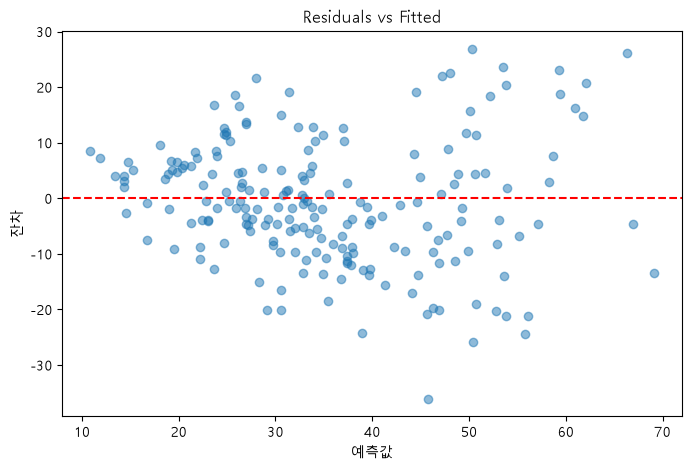

In [72]:
# 잔차를 구하고, 예측값(x축) 대비 잔차(y축) 산점도를 그려 봅시다.
resid = pred_base - y_test

plt.figure(figsize=(8, 5))
plt.scatter(pred_base, resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('예측값'); plt.ylabel('잔차')
plt.title('Residuals vs Fitted')
plt.show()

패턴이 보이시나요? 그럼 **어느 변수가 원인인지** 찾아봅시다.
각 독립변수와 `csMPa`의 관계를 한 번에 그려볼게요.

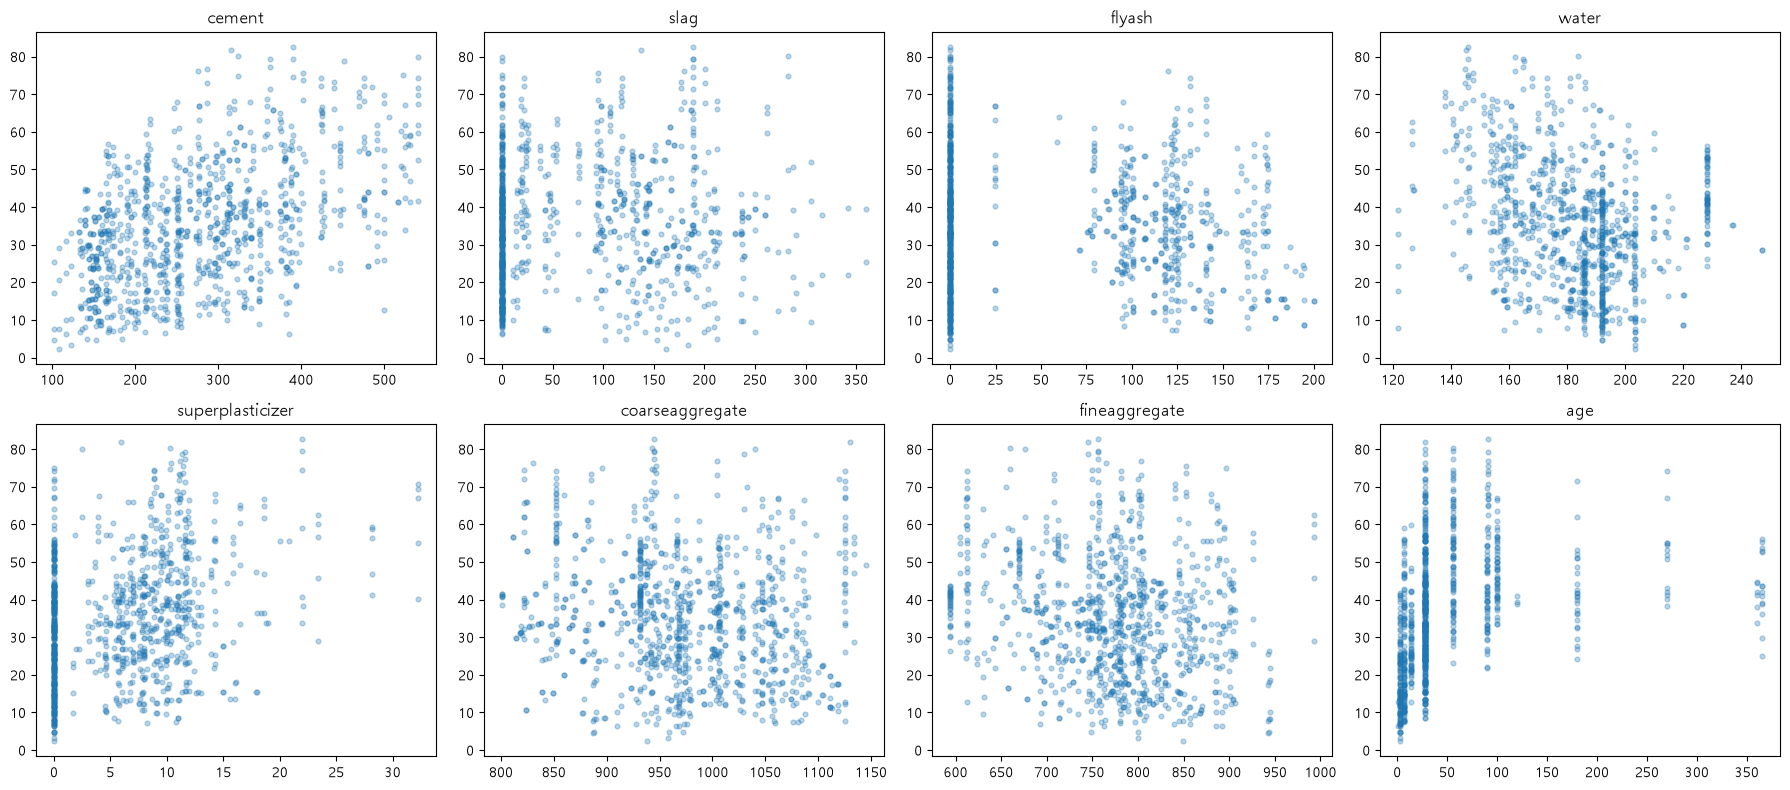

In [73]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), X.columns):
    ax.scatter(data[col], y, alpha=0.3, s=12)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 🤔 잠깐, `age` 그래프가 좀 이상하지 않나요?

여덟 칸 중 `age`만 유독 **세로 줄무늬**처럼 보입니다. 이유가 있어요.

- `age`는 값이 **14가지뿐**입니다. (1, 3, 7, 14, 28, 56, 90, 91, 100, 120, 180, 270, 360, 365일)
  연속적으로 잰 게 아니라 **정해진 시점에만 측정**했거든요. 그래서 같은 x 위에 점이 세로로 쌓입니다.
- 게다가 **데이터의 73%가 28일 이내**에 몰려 있는데 x축은 365까지 뻗어 있어서, 정작 봐야 할 왼쪽이 뭉개져 보여요.

이대로는 관계를 읽기 어렵겠죠? `age`만 따로 떼어 **양생기간별 평균을 겹쳐서** 다시 그려보겠습니다.

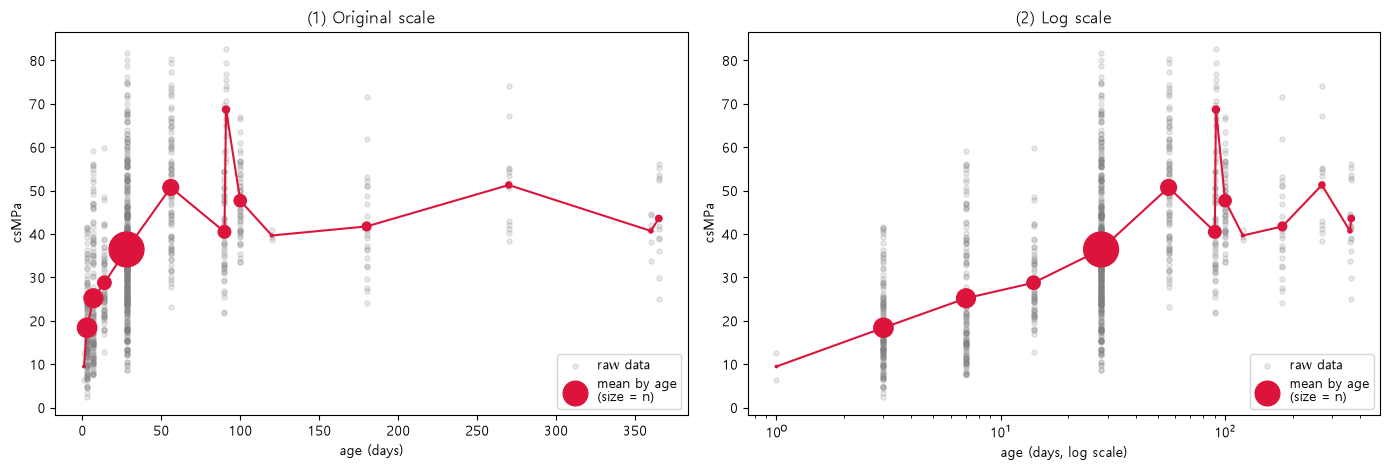

age,1,3,7,14,28,56,90,91,100,120,180,270,360,365
mean,9.5,18.4,25.2,28.8,36.4,50.7,40.5,68.7,47.7,39.6,41.7,51.3,40.7,43.6
count,2.0,129.0,122.0,62.0,419.0,86.0,54.0,17.0,52.0,3.0,26.0,13.0,6.0,14.0


In [74]:
# 그냥 실행해 주세요!
# age만 따로 떼어, 양생기간별 평균(빨간 점)을 겹쳐 그립니다.

age_mean = data.groupby('age')['csMPa'].agg(['mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, use_log, title, xlabel in [
    (axes[0], False, '(1) Original scale', 'age (days)'),
    (axes[1], True,  '(2) Log scale',      'age (days, log scale)'),
]:
    ax.scatter(data['age'], data['csMPa'], alpha=0.18, s=14, color='gray', label='raw data')
    ax.plot(age_mean.index, age_mean['mean'], '-', color='crimson', lw=1.5, zorder=3)
    ax.scatter(age_mean.index, age_mean['mean'], s=age_mean['count'] * 1.5,
               color='crimson', zorder=4, label='mean by age\n(size = n)')
    if use_log:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel); ax.set_ylabel('csMPa'); ax.set_title(title)
    ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

display(age_mean.round(1).T)

> 💡 **빨간 점의 크기 = 그 기간에 측정된 데이터 개수**입니다.
> 점이 크면 믿을 만한 평균이고, 작으면 몇 개 안 되는 값이라 들쭉날쭉할 수 있어요.
>
> 91일 지점이 유독 튀어 올라 있죠? **데이터가 17개뿐이라** 그렇습니다.
> 표를 보시면 56일 이후로 표본이 확 줄어드는 걸 확인할 수 있어요.

**Q.** 위 두 그래프를 보고 답해 주세요.

1. **왼쪽 그래프**에서 빨간 선을 따라가 보세요.
   **1~28일 구간**과 **100~365일 구간** 중, 평균이 더 가파르게 오르는 쪽은 어디인가요?
2. **오른쪽 그래프**(x축만 로그로 바꾼 것)에서 빨간 선은 어떤 모양에 가까워졌나요?
3. 그렇다면 `age`와 `csMPa`의 관계를 **직선 하나로** 표현해도 괜찮을까요?

**A.** 
1. 1~28일 구간입니다.
2. 좀 더 직선 모양에 가까워졌습니다. 
3. 아니요. 로그 축에서 직선이 된다는 건, 원래 축에서는 곡선 모양이라는 뜻입니다.

<details>
<summary><b>▶ 힌트</b></summary>
<br>

- **1번**: 큰 빨간 점 몇 개만 읽어보세요. 3일에 18.4, 28일에 36.4, 365일에 43.6입니다.
  **25일 동안 오른 폭**과 **337일 동안 오른 폭** 중 어느 쪽이 클까요?
- **2번**: x축만 바꿨을 뿐인데 구불구불하던 선이 어떻게 변했는지 보세요.
- **3번**: 로그 축에서 직선이 된다는 건, 원래 축에서는 어떤 모양이라는 뜻일까요?

</details>

---

# Part B

다음으로는 아래와 같은 네 가지 방법으로 모델을 개선해 봅니다!

| | 시도 | 물어볼 것 |
| --- | --- | --- |
| B-1 | `age` 변수 변환 | 왜 하필 로그일까? |
| B-2 | 파생변수 만들기 | 도메인 지식인데 왜 효과가 작을까? |
| B-3 | 규제선형모델 | 같은 규제인데 왜 릿지와 라쏘가 다를까? |
| B-4 | 차원 축소(PCA) | 분산의 95%를 설명하는데 왜 성능이 나빠질까? |


## B-1. `age`를 로그로 바꿔보기

Part A에서 찾은 문제를 고쳐봅시다.

$$ y = a + b \cdot age \quad \rightarrow \quad y = a + b \cdot \log(age) $$

> 💡 **주의** 변환은 항상 train data와 test data, 즉 `X_train`과 `X_test`에 **똑같이** 적용해야 합니다.
> 학습할 때 쓴 형태와 예측할 때 쓴 형태가 다르면 모델이 엉뚱한 값을 내놓을 수 있기 때문이에요.

In [75]:
X_train_log = X_train.copy()
X_test_log = X_test.copy()

# age 칼럼에 자연로그를 씌워 봅시다. (train과 test 모두!)
X_train_log['age'] = np.log(X_train_log['age'])
X_test_log['age'] = np.log(X_test_log['age'])

m_log = LinearRegression().fit(X_train_log, y_train)
pred_log = m_log.predict(X_test_log)

scores.append(report('B-1. age 로그 변환', pred_log))
print(f'train R2: {m_log.score(X_train_log, y_train):.4f}')
display(pd.DataFrame(scores))

train R2: 0.8133


,모델,test R2,test MAE,test RMSE
0,A. baseline (손질 없음),0.5802,8.895,11.191
1,B-1. age 로그 변환,0.8037,5.838,7.652


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(data['age'], data['csMPa'], alpha=0.3, s=14)
axes[0].set_xlabel('age'); axes[0].set_ylabel('csMPa'); axes[0].set_title('변환 전')
axes[1].scatter(np.log(data['age']), data['csMPa'], alpha=0.3, s=14, color='tab:orange')
axes[1].set_xlabel('log(age)'); axes[1].set_ylabel('csMPa'); axes[1].set_title('변환 후')
plt.tight_layout(); plt.show()

**Q.** R²가 얼마나 올랐나요? 그리고 위 두 그래프를 보면서, **로그 변환의 효과가 무엇일지** 설명해 봅시다!

**A.**
R²이 0.2 가까이 늘었다.
로그 변환 효과로 뭉쳐 있던 점들이 퍼져있다. 작은 값들 사이는 넓게, 큰 값들 사이는 좁게 펴주었다. 

<details>
<summary><b>▶ 그래프를 어떻게 볼까요</b></summary>
<br>

왼쪽 그래프에서 점들이 **왼쪽 끝에 잔뜩 뭉쳐 있고** 오른쪽은 텅 비어 있죠?

오른쪽 그래프에서는 점들이 어떻게 배치되어 있나요?

로그 함수는 **작은 값들 사이는 넓게, 큰 값들 사이는 좁게** 펴주는 성질이 있습니다.

</details>

## B-2. 파생변수 만들기

콘크리트 공학에는 잘 알려진 지표가 있어요. 바로 **물-시멘트비(w/c ratio)** 입니다.

$$ w/c\ ratio = \frac{water}{cement} $$

물이 많을수록 반죽은 다루기 쉬워지지만 굳고 나면 약해지고, 시멘트가 많을수록 단단해집니다.
그래서 이 **비율**이 강도를 좌우한다고 알려져 있어요.

파생변수를 만들 때에는 보통 도메인 지식을 많이 활용합니다.
우리도 이 도메인 지식을 가지고 파생변수를 만들어 봐요!

In [76]:
X_train_wc = X_train_log.copy()
X_test_wc = X_test_log.copy()

# water를 cement로 나눈 wc_ratio 칼럼을 만들어 봅시다. (train과 test 모두!)
X_train_wc['wc_ratio'] = X_train_wc['water'] / X_train_wc['cement']
X_test_wc['wc_ratio'] = X_test_wc['water'] / X_test_wc['cement']

m_wc = LinearRegression().fit(X_train_wc, y_train)
pred_wc = m_wc.predict(X_test_wc)

scores.append(report('B-2. + w/c ratio', pred_wc))
display(pd.DataFrame(scores))

,모델,test R2,test MAE,test RMSE
0,A. baseline (손질 없음),0.5802,8.895,11.191
1,B-1. age 로그 변환,0.8037,5.838,7.652
2,B-2. + w/c ratio,0.8068,5.780,7.591


지표가 거의 오르지 않았습니다. 왜일까요? **VIF를 한번 확인해 봅시다.**

In [77]:
def vif_of(df_X):
    Xc = sm.add_constant(df_X)          # 실습에서 배운 그 함수! 잊지 않으셨죠?
    s = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
                  index=Xc.columns)
    return s.drop('const').sort_values(ascending=False)

compare_vif = pd.DataFrame({
    'w/c 추가 전': vif_of(X_train_log).round(2),
    'w/c 추가 후': vif_of(X_train_wc).round(2),
})
display(compare_vif)

,w/c 추가 전,w/c 추가 후
age,1.06,1.07
cement,7.16,11.99
coarseaggregate,5.00,5.01
fineaggregate,7.08,7.08
flyash,6.02,6.02
slag,7.19,7.26
superplasticizer,2.94,2.94
water,6.94,7.43
wc_ratio,NaN,6.92


**Q.** 아래의 질문에 답해 주세요.

1. `wc_ratio`를 추가했더니 **`cement`의 VIF**가 어떻게 변했나요?
2. 도메인 지식으로 만든 좋은 변수인데 왜 성능이 거의 오르지 않았을까요?

**A.**
1. 4.83만큼 커졌습니다.
2. wc_ratio는 water과 cement로 구성되어있기에 모델에게 이 비율은 이미 아는 정보이기 때문이다. 
<details>
<summary><b>▶ 참고</b></summary>
<br>

`wc_ratio`는 `water`와 `cement`로 만들어졌습니다.

그런데 `water`와 `cement`는 **이미 모델 안에 들어 있어요.**

모델 입장에서 `wc_ratio`는 **새로운 정보일지, 이미 아는 정보를 다르게 표현한 것일지 생각해 봅시다.**

</details>

> 🤔 **그래서 `wc_ratio`는 써야 하나요, 말아야 하나요?**
>
> 성능이 0.003 오르는 대신 다중공선성이 심해졌으니, **이번엔 쓰지 않는 편**이 낫겠습니다.

> 앞으로는 **B-1의 모델(`age` 로그 변환)** 을 기준으로 계속 진행할게요.

## B-3. 규제선형모델 — 릿지와 라쏘

실습에서 릿지 모델을 살짝 맛봤었습니다.
`alpha`를 키우면 회귀계수가 눌려 낮아지는 걸 확인했고요.

이번에는 **라쏘 모델까지 함께 놓고** 제대로 비교해 봅시다!

세션에서 배운 망치 비유를 다시 떠올려 볼까요.

> - 🔨 **릿지(L2)** — 기둥에 따라 **다른 힘**으로 누르는 망치. 큰 기둥은 세게, 작은 기둥은 살살.
> - 🔨 **라쏘(L1)** — **모든 기둥을 같은 힘**으로 누르는 망치. 작은 기둥은 못 버티고 사라질 수도.

말로는 알겠는데, 실제로 어떻게 다를까요?

> 💡 **규제 모델은 스케일링이 필수입니다.** 변수마다 단위가 다르면 큰 단위 변수만 억울하게 세게 맞기 때문이에요.
> - **스케일러는 `X_train`으로만 학습**시켜야 합니다.
> - 테스트 데이터의 평균·표준편차까지 알고 있으면 **시험 문제를 미리 본 셈**이 되니까요.

In [78]:
# 스케일러는 X_train으로만 학습시키고, test에는 transform만 적용합니다.
scaler = StandardScaler().fit(X_train_log)
A_train = scaler.transform(X_train_log)
A_test = scaler.transform(X_test_log)

rows = []
for a in [0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=a).fit(A_train, y_train)      # L2 규제 모델
    lasso = Lasso(alpha=a).fit(A_train, y_train)      # L1 규제 모델
    rows.append({
        'alpha': a,
        'Ridge R2': round(r2_score(y_test, ridge.predict(A_test)), 4),
        'Ridge 계수합': round(np.abs(ridge.coef_).sum(), 2),
        'Lasso R2': round(r2_score(y_test, lasso.predict(A_test)), 4),
        'Lasso 계수합': round(np.abs(lasso.coef_).sum(), 2),
        'Lasso 0된 계수': int((np.abs(lasso.coef_) < 1e-8).sum()),
    })

display(pd.DataFrame(rows))

,alpha,Ridge R2,Ridge 계수합,Lasso R2,Lasso 계수합,Lasso 0된 계수
0,0.01,0.8037,47.38,0.8036,46.34,0
1,0.10,0.8037,47.28,0.7991,37.05,0
2,1.00,0.8036,46.41,0.7415,25.19,1
3,10.00,0.8005,40.07,-0.0028,0.00,8
4,100.00,0.7640,29.76,-0.0028,0.00,8


In [79]:
lasso1 = Lasso(alpha=1).fit(A_train, y_train)

display(pd.DataFrame({
    '변수': X_train_log.columns,
    'Lasso 계수 (alpha=1)': lasso1.coef_.round(3),
}).sort_values('Lasso 계수 (alpha=1)', key=abs, ascending=False))

,변수,Lasso 계수 (alpha=1)
7,age,8.570
0,cement,7.558
1,slag,3.466
3,water,-3.288
4,superplasticizer,2.241
6,fineaggregate,-0.050
2,flyash,0.015
5,coarseaggregate,-0.000


**Q.** 표를 보고 아래의 질문에 답해 주세요.

1. `alpha`가 커질 때 **릿지**의 계수합과 R²는 어떻게 변하나요?
2. **라쏘**는 `alpha=10`이 어떻게 변하나요? R²가 **음수**가 나온 건 무슨 뜻일까요?
3. 두 모델의 차이를 **망치 비유로** 설명해 봅시다!

**A.**
1. 릿지 계수 합은 줄어들고,   R²도 줄어들고 있다.
2. 계수가 사라졌다는 의미다.  R² = 0이라는 뜻은 모든 계수가 0이 되어 모델이 평균을 예측한다는 것이고, 음수의 뜻은 평균 예측보다도 성능이 나쁘다는 것이다.
3. 릿지는 기둥에 따라 다른 힘으로 누르는 느낌 , 라쏘는 모든 기둥을 같은 힘으로 누루는 느낌이다.

<details>
<summary><b>▶ 2번의 R² 음수가 이해되지 않는다면</b></summary>
<br>

R²는 **"그냥 평균으로 예측했을 때보다 얼마나 나은가"** 를 재는 지표였습니다.

그럼 R² = 0 이라는 건 **평균으로 예측한 것과 똑같다**는 뜻이겠죠?

모든 계수가 0이 되면 모델은 어떤 값을 내놓게 될까요?

</details>

## B-4. 차원 축소(PCA)

세션에서 다중공선성 대처법으로 **PCA**를 소개했었습니다.

> 💡 상관 있는 변수들을 묶어서 **더 적은 수의 대표 축**으로 바꾸는 것

우리 데이터도 VIF가 5를 넘는 변수가 여럿 있으니 PCA가 도움이 될 수 있을지도 몰라요.

**정말 그럴까요?** 확인해 봅시다.

> ⚠️ **PCA도 스케일링이 필요하고, `X_train`으로만 학습시켜야 합니다.**

,주성분,설명분산 비율,누적 설명분산
0,PC1,0.2828,0.2828
1,PC2,0.1758,0.4586
2,PC3,0.1607,0.6193
3,PC4,0.1354,0.7547
4,PC5,0.1182,0.8729
5,PC6,0.1007,0.9736
6,PC7,0.0225,0.9962
7,PC8,0.0038,1.0000


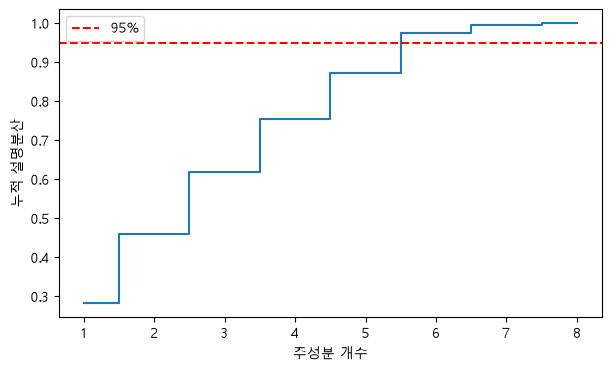

In [80]:
# PCA를 학습시키고 누적 설명분산을 확인해 봅시다. (스케일링된 A_train 사용)
pca_full = PCA().fit(A_train)
cum = np.cumsum(pca_full.explained_variance_ratio_)

display(pd.DataFrame({
    '주성분': [f'PC{i+1}' for i in range(len(cum))],
    '설명분산 비율': pca_full.explained_variance_ratio_.round(4),
    '누적 설명분산': cum.round(4),
}))

plt.figure(figsize=(7, 4))
plt.step(range(1, len(cum) + 1), cum, where='mid')
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.xlabel('주성분 개수'); plt.ylabel('누적 설명분산'); plt.legend()
plt.show()

**6개 주성분이 분산의 97.4%를 설명**하네요. 95% 기준을 넘으니 6개로 줄여서 모델을 만들어 봅시다.

In [81]:
# 주성분 6개로 축소한 뒤 선형회귀를 학습시켜 봅시다.
pca6 = PCA(n_components=6).fit(A_train)
P_train = pca6.transform(A_train)
P_test = pca6.transform(A_test)          # test는 transform만!

m_pca = LinearRegression().fit(P_train, y_train)
pred_pca = m_pca.predict(P_test)

scores.append(report('B-4. PCA 6성분', pred_pca))
display(pd.DataFrame(scores))

,모델,test R2,test MAE,test RMSE
0,A. baseline (손질 없음),0.5802,8.895,11.191
1,B-1. age 로그 변환,0.8037,5.838,7.652
2,B-2. + w/c ratio,0.8068,5.780,7.591
3,B-4. PCA 6성분,0.7349,6.569,8.893


**어라, 성능이 떨어졌네요?** 분산의 97%를 지켰는데 왜 그럴까요?

각 주성분이 **`csMPa`와 얼마나 관련 있는지** 직접 확인해 봅시다.

In [82]:
Z = pca_full.transform(A_train)
corr_with_y = [abs(np.corrcoef(Z[:, i], y_train)[0, 1]) for i in range(Z.shape[1])]

display(pd.DataFrame({
    '주성분': [f'PC{i+1}' for i in range(len(corr_with_y))],
    '설명분산 비율': pca_full.explained_variance_ratio_.round(3),
    'y와의 상관(절댓값)': np.round(corr_with_y, 3),
}))

,주성분,설명분산 비율,y와의 상관(절댓값)
0,PC1,0.283,0.024
1,PC2,0.176,0.101
2,PC3,0.161,0.589
3,PC4,0.135,0.395
4,PC5,0.118,0.317
5,PC6,0.101,0.357
6,PC7,0.023,0.223
7,PC8,0.004,0.149


**Q.** 위 표를 보고 아래 질문에 답해 주세요.

1. **설명분산이 가장 큰 주성분(PC1)** 은 `csMPa`와 얼마나 관련이 있나요?
2. 반대로 **y와 가장 관련 있는 주성분**은 몇 번인가요? 그 주성분의 설명분산 순위는요?
3. 그렇다면 **PCA가 성능을 떨어뜨린 이유**는 무엇일까요?

**A.**
1. 상관력이 떨어진다. 0.024임
2. PC3이고, 설명분산은 3순위다.
3. PCA가 축을 고를 때 x의 분산만 보고 y는 참고하지 않는다. 그러다보니 분산을 가장 잘 설명하는 축인 PC1이 y와는 거의 무관할 수 있고, 반대로 분산 순위가 낮은 축이 y와 더 관련 있을 수 있다. 
<details>
<summary><b>▶ 결정적인 힌트</b></summary>
<br>

PCA는 차원을 줄일 때 **무엇을 기준으로** 축을 고를까요?

주성분을 만드는 과정에서 PCA는 **`y`를 참고했을까요?** 세션자료의 PCA 설명을 다시 떠올려 봅시다.


</details>

## B-5.

우리는 총 네 가지 방법으로 모델을 개선해 보려고 했습니다.
결과를 한 자리에 놓고 비교해 봐요.

,모델,test R2,test MAE,test RMSE
0,A. baseline (손질 없음),0.5802,8.895,11.191
1,B-1. age 로그 변환,0.8037,5.838,7.652
2,B-2. + w/c ratio,0.8068,5.780,7.591
3,B-4. PCA 6성분,0.7349,6.569,8.893


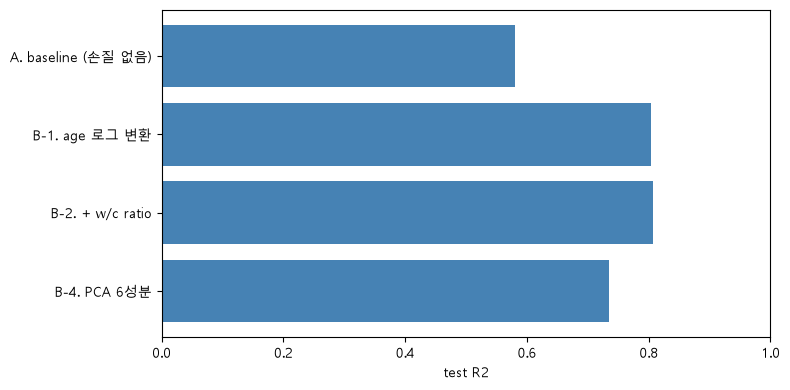

In [83]:
final = pd.DataFrame(scores)
display(final)

plt.figure(figsize=(8, 4))
plt.barh(final['모델'], final['test R2'], color='steelblue')
plt.xlabel('test R2'); plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

**Q.** 최종적으로 어떤 모델을 선택할지, **근거와 함께** 적어 주세요.

- 선택한 모델: B-1
- 근거: R2 값이 0.224로 가장 큰 상승을 했다. 변수를 적게 사용하면서도 즉 단순하면서도 예측력이 가장 높기 때문이다. 

그리고 이번 Part B에서 **가장 크게 성능을 올린 시도**는 무엇이었나요?
그 이유와 이번 실습을 통해 얻은 인사이트를 정리해 봅시다.

**A.**
가장 크게 성능을 올린 시도는 로그변환이다. 복잡하게 변수를 추가하지 않아도 단순하게 데이터를 설명할 수 있는 방법이 로그변환이기에, 성능을 높이기 위해 꼭 시도해봐야겠다는 생각이 들었다. 분석의 목적은 예측이기 때문에 성능을 높이는 것은 중요하다. 

<details>
<summary><b>▶ 무엇을 근거로 삼아야 할까요</b></summary>
<br>

모든 모델은 성능 숫자만이 근거가 되지 않습니다.

**해석 가능성**(회귀계수를 설명할 수 있는가), **단순함**(변수가 적은가), **다중공선성** 같은 것도 함께 봐야 하기 때문이죠.

세션에서 이야기했던 **"분석의 목적이 설명인가 예측인가"** 도 판단 기준이 됩니다.

</details>

---

# Part C · 회귀분석 도전!!


이번에는 새로운 데이터를 가지고, 직접 모델을 설계해 회귀분석을 처음부터 끝까지 수행해 봅시다!

---

## 데이터 소개 — King County 집값

미국 워싱턴주 King County(시애틀 일대)에서 **2014~2015년에 실제로 거래된 주택 21,613건**의 기록이에요.
> **우리는 `price`를 종속변수로 두어 집값을 예측하는 모델을 설계합니다!**

| 칼럼 | 뜻 | | 칼럼 | 뜻 |
| --- | --- | --- | --- | --- |
| `price` | **집값 (종속변수)** | | `sqft_above` | 지하 제외 면적 |
| `date` | 매각 날짜 | | `sqft_basement` | 지하실 면적 |
| `bedrooms` | 침실 수 | | `yr_built` | 건축 연도 |
| `bathrooms` | 욕실 수 | | `yr_renovated` | 리모델링 연도 |
| `sqft_living` | 주거 면적 | | `zipcode` | 우편번호 |
| `sqft_lot` | 부지 면적 | | `lat` / `long` | 위도 / 경도 |
| `floors` | 층수 | | `sqft_living15` | 인근 15채 평균 주거면적 |
| `waterfront` | 물가 조망 여부 (0/1) | | `sqft_lot15` | 인근 15채 평균 부지면적 |
| `view` | 조망 점수 | | `condition` | 상태 등급 |
| `grade` | 주택 등급 | | `id` | 고유 번호 |

---

## 조건

1. **EDA**를 통해 데이터를 파악하고, 눈에 띄는 점을 정리한다
2. 사용할 **독립변수를 직접 고른다** (고른 이유를 밝힐 것)
3. **baseline 모델**을 만든다
4. **모델 개선 방법을 두 가지 이상 시도**하고, 각각 성능이 어떻게 변했는지 기록한다
5. 최종 모델을 정하고, **결론을** 정리한다

> ⚠️ `id`는 고유 번호일 뿐이라 예측에 쓸 수 없으니 반드시 제외해야 합니다!

In [84]:
df = pd.read_csv('./kc_house_data.csv')   # 경로가 다르면 맞게 수정해 주세요
print(df.shape)
df.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## C-1. 데이터 탐색


In [85]:
# 결측치, 중복, 기술통계 등을 확인해 보세요.

print(df.info())
print(df.duplicated().sum())
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Q.** 데이터를 살펴보며 눈에 띈 점을 **세 가지 이상** 적어 주세요.

**A.**
1. 가격 데이터의 표준편차가 367127로 가장 분포가 널리 퍼져있는 데이터다.
2. bathrooms 욕실 수가 float(실수형) 데이터다.
3. 중복된 데이터 값은 없다. 
4. bedrooms(방 개수)의 75%값이 4개인데 max는 33개로 적혀있는데. 눈에 띄는 이상치 같다. 오입력일 수도 있을 것이다.



## C-2. 변수 선택하기

In [86]:
# 사용할 독립변수를 골라 보세요.
# 힌트: 상관계수, VIF, 그리고 '이 변수가 의미가 있는가'를 함께 생각해 보세요.

A = df[['sqft_living', 'grade', 'bathrooms']]
b = df[['price']]

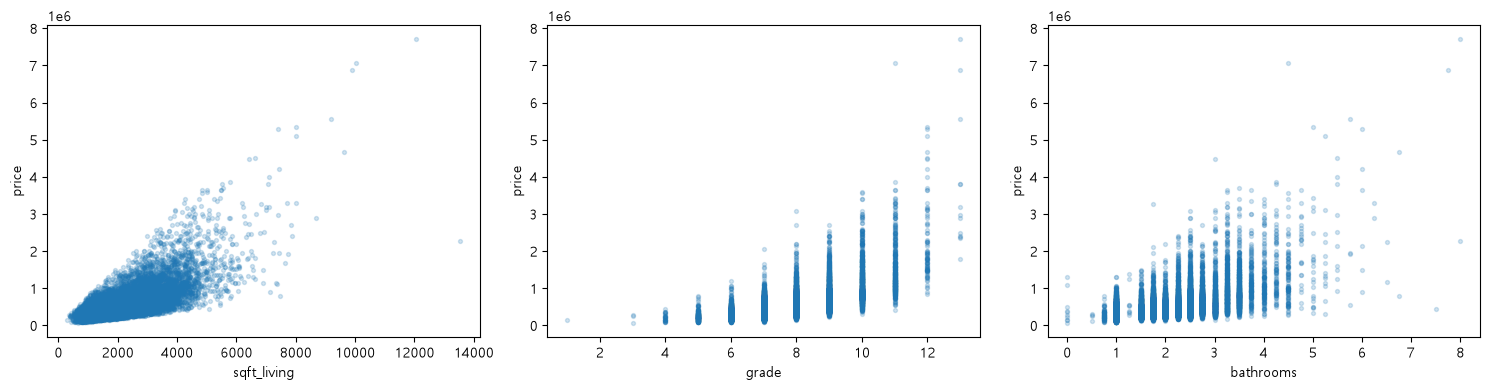

             sqft_living     grade  bathrooms
sqft_living     1.000000  0.762704   0.754665
grade           0.762704  1.000000   0.664983
bathrooms       0.754665  0.664983   1.000000
sqft_living    3.241685
grade          2.501767
bathrooms      2.430875
dtype: float64


In [87]:
# 선형성: 각 변수와 price의 관계가 직선에 가까운지 확인
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, A.columns):
    ax.scatter(df[col], df['price'], alpha=0.2, s=8)
    ax.set_xlabel(col); ax.set_ylabel('price')
plt.tight_layout()
plt.show()

# 독립성(다중공선성): 변수들끼리 상관계수 + VIF
print(A.corr())

def vif_of(df_X):
    Xc = sm.add_constant(df_X)
    s = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
                  index=Xc.columns)
    return s.drop('const').sort_values(ascending=False)

print(vif_of(A))


**Q.** 최종적으로 어떤 변수들을 골랐나요? **고른 이유**도 함께 적어 주세요.

**A.** 'sqft_living', 'grade', 'bathrooms'세 변수가 가격과의 상관관계가 높고 VIF 지수가 낮아 집 값을 예측할 수 있는 힘이 클 것 같아 골랐다.

## C-3. Baseline 모델

In [91]:
# 데이터를 나누고, baseline 선형회귀 모델을 만들어 보세요.
# 성능은 test 기준으로 R2, MAE, RMSE를 모두 확인하면 좋습니다.

A_train, A_test, b_train, b_test = train_test_split(
    A, b, test_size=0.2, random_state=42
)

print(f'train: {len(A_train)}개 / test: {len(A_test)}개')

base = LinearRegression().fit(A_train, b_train)
pred_base = base.predict(A_test)

def report(name, model_pred, b_true=None):
    b_true = b_test if b_true is None else b_true
    return {
        '모델': name,
        'test R2': round(r2_score(b_true, model_pred), 4),
        'test MAE': round(mean_absolute_error(b_true, model_pred), 3),
        'test RMSE': round(np.sqrt(mean_squared_error(b_true, model_pred)), 3),
    }

scores = [report('C. baseline (손질 없음)', pred_base)]
print(f'train R2: {base.score(A_train, b_train):.4f}')
display(pd.DataFrame(scores))


train: 17290개 / test: 4323개
train R2: 0.5355


,모델,test R2,test MAE,test RMSE
0,C. baseline (손질 없음),0.5421,166449.696,263117.625


## C-4. 개선 시도 (2가지 이상)

Part B에서 써본 방법들을 떠올려 봅시다. 이 데이터에는 어떤 방법이 적절할까요?

In [92]:
# 개선 시도 ①

A_train_log = A_train.copy()
A_test_log = A_test.copy()
A_train_log['sqft_living'] = np.log(A_train_log['sqft_living'])
A_test_log['sqft_living'] = np.log(A_test_log['sqft_living'])

b_train_log = np.log(b_train)
b_test_log = np.log(b_test)

m_log = LinearRegression().fit(A_train_log, b_train_log)
pred_log_scale = m_log.predict(A_test_log)
pred_log = np.exp(pred_log_scale)

scores.append(report('C-1. sqft_living/price 로그 변환', pred_log))
print(f'train R2 (로그 스케일): {m_log.score(A_train_log, b_train_log):.4f}')
display(pd.DataFrame(scores))


train R2 (로그 스케일): 0.5428


,모델,test R2,test MAE,test RMSE
0,C. baseline (손질 없음),0.5421,166449.696,263117.625
1,C-1. sqft_living/price 로그 변환,0.5499,154527.230,260861.442


In [93]:
# 개선 시도 ②

scaler = StandardScaler().fit(A_train_log)
A_train_scaled = scaler.transform(A_train_log)
A_test_scaled = scaler.transform(A_test_log)

rows = []
for a in [0.01, 0.1, 1, 10, 100]:
    ridge = Ridge(alpha=a).fit(A_train_scaled, b_train_log)
    lasso = Lasso(alpha=a).fit(A_train_scaled, b_train_log)
    rows.append({
        'alpha': a,
        'Ridge R2': round(r2_score(b_test_log, ridge.predict(A_test_scaled)), 4),
        'Ridge 계수합': round(np.abs(ridge.coef_).sum(), 2),
        'Lasso R2': round(r2_score(b_test_log, lasso.predict(A_test_scaled)), 4),
        'Lasso 계수합': round(np.abs(lasso.coef_).sum(), 2),
        'Lasso 0된 계수': int((np.abs(lasso.coef_) < 1e-8).sum()),
    })
display(pd.DataFrame(rows))


best_ridge = Ridge(alpha=0.01).fit(A_train_scaled, b_train_log)
pred_ridge = np.exp(best_ridge.predict(A_test_scaled))

scores.append(report('C-2. Ridge 규제 (alpha=0.01)', pred_ridge))
display(pd.DataFrame(scores))



,alpha,Ridge R2,Ridge 계수합,Lasso R2,Lasso 계수합,Lasso 0된 계수
0,0.01,0.5613,0.43,0.5602,0.4,1
1,0.10,0.5613,0.43,0.5156,0.3,1
2,1.00,0.5613,0.43,-0.0006,0.0,3
3,10.00,0.5613,0.43,-0.0006,0.0,3
4,100.00,0.5611,0.42,-0.0006,0.0,3


,모델,test R2,test MAE,test RMSE
0,C. baseline (손질 없음),0.5421,166449.696,263117.625
1,C-1. sqft_living/price 로그 변환,0.5499,154527.230,260861.442
2,C-2. Ridge 규제 (alpha=0.01),0.5499,154527.233,260861.473


**Q.** 각 시도가 모델의 성능을 어떻게 바꿨나요? **효과가 있었던 것과 없었던 것**을 나눠 정리해 주세요.

| 시도 | test R² | 효과 | 왜 그랬을까 |
| --- | --- | --- | --- |
| baseline |0.5421| | |
| 시도 ① |0.5499  |미미|면적이 뭉쳐져 있었는데 로그로 이를 펴지게 할 수 있다.|
| 시도 ② |0.5499 |미미|애초에 세 변수의 VIF가 5미만이어서 다중공선성이 크지 않았다. 따라서 릿지는 크게 줄지 않았다. 반면 라쏘는 alpha=0.01부터 변수의 개수를 0부터 만들었다. |

**A.**
시도 (1)의 로그변환이 효과가 시도 (2) 보다는 있었다. 면적과 가격의 관계가 뭉쳐져 있는데 이것을 로그 변환으로 펴지게 할 수 있었다. 
VIF 지수가 작기에 릿지/라쏘 변환이 큰 효과가 없었음을 알 수 있었다.


## C-5. 결론

모델을 통해 얻은 결과를 정리해 주세요!

---

**A.** 
이 분석에서는 로그변환을 활용해야 할 것이다. 시도2와 시도1의 결과값은 동일한데 시도2는 시도1보다 복잡한 규제들을 추가하므로, 더 단순한 로그변환을 최종모델로 사용해야 한다. <BR>
세 변수의 다중공선성이 양호한 수준으로 나왔을 때는 릿지와 라쏘의 효과가 크게 없을 수 있다는 것을 깨달았다. 전에 콘크리트는 VIF지수가 7이 넘어 릿지와 라쏘의 효과가 있었음을 비교할 수 있었다. <BR>
결론적으로, 변수를 신중히 선택해야 하고 회귀분석 전에 선형성과 독립성 체크를 통해서 어떤 모델을 사용해야 할지도 깊게 생각해봐야 한다는 것을 깨달았다.




---

## 마무리

이번 과제에서는 회귀 모델을 직접 만들고, 모델을 개선해 보는 과정을 거쳤습니다.


그리고 모델을 개선할 때 발견했던 것들도 다시 한번 기억해 주세요!

1. **`age` 로그 변환** — 데이터에 맞는 형태를 찾는 것이 복잡한 모델보다 더 적합한 모델일 때가 있습니다. (0.58 → 0.80)
2. **`w/c ratio`** — 도메인 지식으로 만든 변수라도, **이미 있는 정보의 재조합이면** 도움이 되지 않는 경우가 많습니다.
3. **릿지 vs 라쏘** — 데이터에 따라 어떤 규제를 사용할지를 결정해야 해요.
4. **PCA** — 분산을 잘 설명하는 축과 **y를 잘 설명하는 축은 다릅니다.** PCA는 y를 보지 않으니까요!

수고 많으셨습니다! 다음 세션에서 만나요 👋